# Does V-JEPA 2 encode motion, or mostly appearance?

Take a video clip, get its embedding from a frozen encoder, scramble
time, and measure how far the embedding moved.

**Three perturbations**

- **reversed**: frames played backwards. Motion stays natural. Only the arrow of time is wrong.
- **shuffled**: random frame order. Destroys motion continuity, but also
  introduces jump cuts and changes what goes into each tubelet, so this
  condition is confounded.
- **static**: the middle frame repeated. No motion at all.

**The metric**

Temporal sensitivity is the cosine distance between a clip's original
and perturbed embedding, divided by that clip's mean cosine distance to
the other clips' originals.

Zero means the perturbation moved nothing. One means it moved the
embedding as far as substituting a completely different video.

**Two controls, answering different questions**

DINOv2 run frame by frame and averaged over time cannot see frame order
at all. It must score zero on reversed and shuffled up to floating-point accumulation error. Anything larger indicates a fault in the measurement.

A randomly initialized V-JEPA 2 shares the architecture but has learned
nothing. The patch embedding is a Conv3d two frames deep whose kernel
weights differ between those two positions, so even an untrained network
can register reversal. This control says how much of the result the
architecture alone could produce.

No training anywhere. Frozen encoders, forward passes only.

**Result.** Reversing a clip moves V-JEPA 2's embedding to 0.0720 of the distance to an unrelated clip. Shuffling it moves the embedding about four times further. Both controls confirm the measurement: an order-blind encoder scores zero, and
the same architecture with untrained weights scores more than two orders of magnitude lower than the trained one.

## How this notebook is organised

    Setup and protocol
      │   config.yaml, written before any result was seen
      │   dataset pinned to a commit hash
      ▼
    Perturbations
      │   three frame-level functions
      │   assertions that fail loudly if one silently does nothing
      ▼
    Encoders
      │   DINOv2        control: is the metric sound?
      │   V-JEPA 2      the model under study
      │   random-init   control: what does architecture alone give?
      ▼
    Statistics
      │   bootstrap confidence intervals
      │   Wilcoxon signed-rank tests
      ▼
    Robustness
      │   max pooling, L1 and L2 distance
      │   centered embeddings, cross-action denominator
      ▼
    Results and plots

| Model | What it tells us |
| :--- | :--- |
| DINOv2 | Order-blind by construction, so its score on reversed and shuffled is a known answer. Confirms the pipeline measures temporal change. |
| random-init | Same architecture as V-JEPA, untrained weights. Separates what the network's shape produces from what pretraining produced. |
| V-JEPA 2 | The model under study, measured against both. |

The two controls bound different quantities. DINOv2 bounds measurement error. The random-init encoder bounds the architecture's own contribution.

In [6]:
!pip install -q "transformers>=4.53.0" torchcodec

In [7]:
import yaml, torch
from pathlib import Path
from huggingface_hub import snapshot_download
from transformers import AutoVideoProcessor, AutoModel
from torchcodec.decoders import VideoDecoder
import numpy as np
import pandas as pd 
from scipy.stats import wilcoxon

print(torch.cuda.is_available(), torch.cuda.get_device_name(0))

True Tesla T4


## Frozen protocol

Everything that defines a run lives in one file, written before any
results were seen. The dataset is pinned to an exact commit, so
"all validation clips from these three actions" resolves to the same
30 files every time.

In [8]:
%%writefile config.yaml
model:
  checkpoint: facebook/vjepa2-vitl-fpc64-256
  dino_checkpoint: facebook/dinov2-base
  pooling: mean         
  secondary_pooling: max
  random_init_seed: 42

data:
  repo_id: nateraw/kinetics-mini
  repo_type: dataset
  revision: 9f4ed38128a355c352527209101be3e326471816
  split: val
  actions:
    - archery
    - bowling
    - high_jump
  selection: all
  num_frames: 64

perturbation:
  bootstrap_seed: 21
  bootstrap_n: 10000
  shuffle_seed: 42

Overwriting config.yaml


In [9]:
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)
print(cfg)

{'model': {'checkpoint': 'facebook/vjepa2-vitl-fpc64-256', 'dino_checkpoint': 'facebook/dinov2-base', 'pooling': 'mean', 'secondary_pooling': 'max', 'random_init_seed': 42}, 'data': {'repo_id': 'nateraw/kinetics-mini', 'repo_type': 'dataset', 'revision': '9f4ed38128a355c352527209101be3e326471816', 'split': 'val', 'actions': ['archery', 'bowling', 'high_jump'], 'selection': 'all', 'num_frames': 64}, 'perturbation': {'bootstrap_seed': 21, 'bootstrap_n': 10000, 'shuffle_seed': 42}}


In [10]:
from kaggle_secrets import UserSecretsClient
token = UserSecretsClient().get_secret("HUGGING_FACE_TOKEN")

DATA_ROOT = Path(snapshot_download(
    repo_id=cfg["data"]["repo_id"],
    repo_type=cfg["data"]["repo_type"],
    revision=cfg["data"]["revision"],
    allow_patterns=[f"{cfg['data']['split']}/{a}/*" for a in cfg["data"]["actions"]],
    token=token,
))

clip_paths = sorted(DATA_ROOT.rglob("*.mp4"))
print(len(clip_paths))

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

30


In [11]:
from transformers import AutoVideoProcessor, AutoModel , AutoProcessor
from kaggle_secrets import UserSecretsClient

token = UserSecretsClient().get_secret("HUGGING_FACE_TOKEN")

vjepa_model = AutoModel.from_pretrained(cfg["model"]["checkpoint"], token=token)
vjepa_processor = AutoVideoProcessor.from_pretrained(cfg["model"]["checkpoint"], token=token)
vjepa_model.eval()

vjepa_model.to("cuda")

config.json:   0%|          | 0.00/785 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.30G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

video_preprocessor_config.json: 0.00B [00:00, ?B/s]

VJEPA2Model(
  (encoder): VJEPA2Encoder(
    (embeddings): VJEPA2Embeddings(
      (patch_embeddings): VJEPA2PatchEmbeddings3D(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (layer): ModuleList(
      (0-23): 24 x VJEPA2Layer(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attention): VJEPA2RopeAttention(
          (query): Linear(in_features=1024, out_features=1024, bias=True)
          (key): Linear(in_features=1024, out_features=1024, bias=True)
          (value): Linear(in_features=1024, out_features=1024, bias=True)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): VJEPA2MLP(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (activation): GELUActivation()
          (fc

## Pipeline check

One clip end to end: decode, preprocess, forward pass. We also confirm
every clip has at least 64 frames, and time a single pass to size the
full run.

The output shape is (1, 8192, 1024). The patch embedding is a Conv3d with kernel (2, 16, 16), so every 2 frames x 16x16 pixels becomes one token. 64 / 2 = 32 in time. 256 / 16 = 16 per spatial side. 32 x 16 x 16 = 8192 tokens, each 1024 numbers wide.

In [12]:
from torchcodec.decoders import VideoDecoder
import time

## checking for time
torch.cuda.synchronize()
start_time = time.time()
required_frames = cfg["data"]["num_frames"]
reference_video_url = clip_paths[0]
decoder = VideoDecoder(reference_video_url, device="cuda")


frame_indices = list(range(0 , required_frames))

raw_video_tensor = decoder.get_frames_at(indices = frame_indices).data

print(decoder.metadata)

print(raw_video_tensor.shape, raw_video_tensor.dtype)

inputs = vjepa_processor(raw_video_tensor ,return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = vjepa_model(**inputs)
    features = outputs.last_hidden_state

torch.cuda.synchronize()
end_time = time.time()

clip_duration = end_time - start_time

for p in clip_paths:
    n = VideoDecoder(p).metadata.num_frames
    if n < cfg["data"]["num_frames"]:
        print("TOO SHORT:", p.name, n)
print("checked", len(clip_paths))
print(f"the GPU time required for each clip is {clip_duration}")
print(f"Pipeline verified! Extracted features shape: {features.shape}")

VideoStreamMetadata:
  duration_seconds_from_header: 10.01
  begin_stream_seconds_from_header: 0.0
  bit_rate: 850570.0
  codec: h264
  stream_index: 0
  duration_seconds: 10.01
  begin_stream_seconds: 0.0
  begin_stream_seconds_from_content: 0.0
  end_stream_seconds_from_content: 10.01
  width: 480
  height: 360
  num_frames_from_header: 300
  num_frames_from_content: 300
  average_fps_from_header: 29.97003
  pixel_aspect_ratio: 1
  end_stream_seconds: 10.01
  num_frames: 300
  average_fps: 29.97003

torch.Size([64, 3, 360, 480]) torch.uint8
checked 30
the GPU time required for each clip is 8.02675461769104
Pipeline verified! Extracted features shape: torch.Size([1, 8192, 1024])


## Perturbations

All three act on the raw (T, C, H, W) tensor, before the processor.
Perturbations act on frames, not tokens. V-JEPA applies 3D positional encoding over tubelets, so a token-level shuffle would correspond to no real video.

In [13]:
def reverse_clip(raw_video_tensor):
    flipped_tensor = torch.flip(raw_video_tensor , dims =[0])
    return flipped_tensor
    

In [14]:
def shuffle_clip(frames: torch.Tensor, seed: int) -> torch.Tensor:
    """
    Shuffles frames along the temporal dimension (T, C, H, W) deterministically.
    """
    # 1. Inspect the time dimension length (T)
    num_frames = frames.shape[0]

    # 2. Set up an isolated CPU generator for reproducibility
    generator = torch.Generator().manual_seed(seed)

    # 3. Generate deterministic permuted indices [0, num_frames - 1]
    permuted_indices = torch.randperm(num_frames, generator=generator)

    # Ensure indices reside on the same device as the video frames 
    permuted_indices = permuted_indices.to(frames.device)

    # 4. Reorder along dimension 0 via tensor indexing
    shuffled_frames = frames[permuted_indices]

    return shuffled_frames

In [15]:
def make_static_clip(frames: torch.Tensor) -> torch.Tensor:
    """
    Takes the middle frame and repeats it T times along the time axis,
    preserving the original (T, C, H, W) shape.
    """
    T = frames.shape[0]
    mid_idx = T // 2
    
    # Extract middle frame while keeping dimension 0: shape becomes (1, C, H, W)
    mid_frame = frames[mid_idx : mid_idx + 1]
    
    # Repeat along the time dimension T times without altering C, H, W
    static_frames = mid_frame.repeat(T, 1, 1, 1)
    
    return static_frames

## Perturbation tests

A broken perturbation function does not crash. It returns a well-formed tensor and a plausible number, so the fault never surfaces as an error.

So each function is tested for something that would fail loudly if it
silently did nothing:

- reverse: output differs from input, and reversing twice returns the
  original exactly
- shuffle: same seed gives identical output, output differs from input,
  and the pixel totals are unchanged (frames rearranged, not altered)
- static: every frame equals the middle frame

Run across all 30 clips.

In [16]:
def validate_clip_perturbations(raw_video_tensor , seed):

    # Reversal Tests 
    reversed_frames = reverse_clip(raw_video_tensor)

    assert not torch.equal(raw_video_tensor, reversed_frames), "Failed: Reversed clip is exactly the same as the original."

    assert torch.equal(raw_video_tensor, reverse_clip(reversed_frames)), "Failed: Double reversal did not match the original."

    ## Shuffling tests
    shuffled_run_1 = shuffle_clip(raw_video_tensor, seed=seed)
    shuffled_run_2 = shuffle_clip(raw_video_tensor, seed=seed)
    
    # Test 1: Determinism 
    assert torch.equal(shuffled_run_1, shuffled_run_2), (
        "Failed Test 1: Shuffling is non-deterministic across runs with the same seed."
    )
    
    # Test 2: Transformation Check
    assert not torch.equal(raw_video_tensor, shuffled_run_1), (
        "Failed Test 2: Shuffled clip is identical to original input."
    )
    
    # Test 3: Conservation of Contents
    assert shuffled_run_1.shape == raw_video_tensor.shape, (
        f"Failed Test 3A: Shape mismatch. Expected {raw_video_tensor.shape}, got {shuffled_run_1.shape}"
    )
    
    # B: Value preservation 
    assert torch.equal(
        torch.sum(raw_video_tensor.to(torch.int64)), 
        torch.sum(shuffled_run_1.to(torch.int64))
    ), "Failed Test 3B: Pixel sum changed; frames were corrupted or altered during shuffle."


    ### Static tests
    static_clip = make_static_clip(raw_video_tensor)

    # Test 1: Shape Preservation
    assert static_clip.shape == raw_video_tensor.shape, (
        f"Expected shape {raw_video_tensor.shape}, got {static_clip.shape}"
    )
    
    # Test 2: Frame Identity Across Time 
    mid_frame = raw_video_tensor[raw_video_tensor.shape[0] // 2]
    for t in range(static_clip.shape[0]):
        assert torch.equal(static_clip[t], mid_frame), (
            f"Frame at index {t} does not match the reference middle frame."
        )
    
    # Test 3: Transformation Check (Assuming non-static source video)
    assert not torch.equal(raw_video_tensor, static_clip), (
        "Original clip was already identical to static middle frame."
    )
        
    

In [17]:
seed = cfg["perturbation"]["shuffle_seed"]
num_frames = cfg["data"]["num_frames"]
frame_indices = list(range(0, num_frames))

for idx, clip_path in enumerate(clip_paths, 1):
    print(f"Testing clip [{idx}/{len(clip_paths)}]: {clip_path.name}")

    decoder = VideoDecoder(clip_path, device="cuda")
    raw_video_tensor = decoder.get_frames_at(indices=frame_indices).data

    validate_clip_perturbations(raw_video_tensor, seed)

print(f"All {len(clip_paths)}/{len(clip_paths)} clips passed!")

Testing clip [1/30]: -Qz25rXdMjE_000014_000024.mp4
Testing clip [2/30]: -UJgyiWe500_000029_000039.mp4
Testing clip [3/30]: 0S-P4lr_c7s_000022_000032.mp4
Testing clip [4/30]: 27jJKXiB9Y8_000009_000019.mp4
Testing clip [5/30]: 2x1lIrgKxYo_000589_000599.mp4
Testing clip [6/30]: 36E29x22tnQ_000018_000028.mp4
Testing clip [7/30]: 3and4vWkW4s_000011_000021.mp4
Testing clip [8/30]: 3hoSk280ndk_000025_000035.mp4
Testing clip [9/30]: 4hxnP0stMN0_000003_000013.mp4
Testing clip [10/30]: 4wXnaqEDh3c_000014_000024.mp4
Testing clip [11/30]: --dVV4_CSvw_000033_000043.mp4
Testing clip [12/30]: -WH-lxmGJVY_000005_000015.mp4
Testing clip [13/30]: -jOClYqKtE8_000003_000013.mp4
Testing clip [14/30]: 1W7HNDBA4pA_000002_000012.mp4
Testing clip [15/30]: 4JxH3S5JwMs_000003_000013.mp4
Testing clip [16/30]: 5NLQMrXzCQA_000003_000013.mp4
Testing clip [17/30]: 5P0Szq9VDYg_000021_000031.mp4
Testing clip [18/30]: 5Vu8HJ__eMg_000277_000287.mp4
Testing clip [19/30]: 6V6DgC9u7Y0_000000_000010.mp4
Testing clip [20/30]:

## DINOv2 control


DINOv2 is an image model run on each frame separately, then averaged.
Averaging ignores order, so reversed and shuffled *must* produce the
same embedding as the original, up to floating-point accumulation error. The expected value is known in advance, so a deviation identifies a fault in the measurement.

Static is different. It replaces 63 frames with copies of one frame, so
the picture content genuinely changes. DINOv2 is expected to score above zero on static, since the image content changes.

In [18]:
token = UserSecretsClient().get_secret("HUGGING_FACE_TOKEN")

dino_checkpoint = cfg["model"]["dino_checkpoint"]
dino_processor = AutoProcessor.from_pretrained(dino_checkpoint , token= token)
dino_model = AutoModel.from_pretrained(dino_checkpoint ,token= token).to("cuda")

dino_model.eval()

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

### Why the CLS token

DINOv2 returns 257 vectors per frame: one CLS token and 256 patch
tokens. We need one vector per frame, so we take the CLS token. It is
what DINOv2 was trained to use as a summary of the whole image, and it
needs no extra pooling step.


In [19]:
def encode_dinov2_clip(frames):

    inputs = dino_processor(images = frames , return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = dino_model(**inputs)
        last_hidden_state = outputs.last_hidden_state

    cls_vector = last_hidden_state[:,0,:]

    embedding_avg = torch.mean(cls_vector , dim = 0)

    return embedding_avg
        

Three checks. Reversed and shuffled must match the original exactly.
Static must not, since the picture genuinely changed.

In [20]:
emb = encode_dinov2_clip(raw_video_tensor)
print(emb.shape)

torch.Size([768])


In [21]:
a = encode_dinov2_clip(raw_video_tensor)
b = encode_dinov2_clip(shuffle_clip(raw_video_tensor,seed))
print(torch.allclose(a, b, atol=1e-5))

True


In [22]:
a = encode_dinov2_clip(raw_video_tensor)
b = encode_dinov2_clip(make_static_clip(raw_video_tensor))
print(torch.allclose(a, b, atol=1e-5))

False


In [23]:
emb_path = Path("/kaggle/working/dino_embeddings.pt")

if emb_path.exists():
    embeddings = torch.load(emb_path)
else:
    embeddings= {}
    for idx, clip in enumerate(clip_paths, 1):
        print(f"[{idx}/{len(clip_paths)}] {clip.name}")
    
        decoder = VideoDecoder(clip, device="cuda")
        raw_video_tensor = decoder.get_frames_at(indices=frame_indices).data
    
        emb         = encode_dinov2_clip(raw_video_tensor)
        reverse_emb = encode_dinov2_clip(reverse_clip(raw_video_tensor))
        shuffle_emb = encode_dinov2_clip(shuffle_clip(raw_video_tensor, seed))
        static_emb  = encode_dinov2_clip(make_static_clip(raw_video_tensor))
    
        assert torch.allclose(emb, reverse_emb, atol=1e-5), f"reverse failed: {clip.name}"
        assert torch.allclose(emb, shuffle_emb, atol=1e-5), f"shuffle failed: {clip.name}"
        assert not torch.allclose(emb, static_emb, atol=1e-5), f"static failed: {clip.name}"
    
        embeddings[(clip.name, "original")] = emb.cpu()
        embeddings[(clip.name, "reversed")] = reverse_emb.cpu()
        embeddings[(clip.name, "shuffled")] = shuffle_emb.cpu()
        embeddings[(clip.name, "static")]   = static_emb.cpu()

print(len(embeddings))

[1/30] -Qz25rXdMjE_000014_000024.mp4
[2/30] -UJgyiWe500_000029_000039.mp4
[3/30] 0S-P4lr_c7s_000022_000032.mp4
[4/30] 27jJKXiB9Y8_000009_000019.mp4
[5/30] 2x1lIrgKxYo_000589_000599.mp4
[6/30] 36E29x22tnQ_000018_000028.mp4
[7/30] 3and4vWkW4s_000011_000021.mp4
[8/30] 3hoSk280ndk_000025_000035.mp4
[9/30] 4hxnP0stMN0_000003_000013.mp4
[10/30] 4wXnaqEDh3c_000014_000024.mp4
[11/30] --dVV4_CSvw_000033_000043.mp4
[12/30] -WH-lxmGJVY_000005_000015.mp4
[13/30] -jOClYqKtE8_000003_000013.mp4
[14/30] 1W7HNDBA4pA_000002_000012.mp4
[15/30] 4JxH3S5JwMs_000003_000013.mp4
[16/30] 5NLQMrXzCQA_000003_000013.mp4
[17/30] 5P0Szq9VDYg_000021_000031.mp4
[18/30] 5Vu8HJ__eMg_000277_000287.mp4
[19/30] 6V6DgC9u7Y0_000000_000010.mp4
[20/30] 8TiYnWFX-ow_000042_000052.mp4
[21/30] 01fAWEHzudA_000002_000012.mp4
[22/30] 0oL36GHlSXw_000022_000032.mp4
[23/30] 3sBYgcb4bEY_000003_000013.mp4
[24/30] 4DP5vsyAg1c_000003_000013.mp4
[25/30] 4Zcjoek-1-4_000003_000013.mp4
[26/30] 5RIe5niLskU_000004_000014.mp4
[27/30] 5gVK5JsNRSc_0

In [24]:
def _distance(a, b, metric):
    if metric == "cosine":
        return 1.0 - torch.nn.functional.cosine_similarity(a, b, dim=0)
    elif metric == "l1":
        return torch.nn.functional.l1_loss(a, b, reduction="mean")
    elif metric == "l2":
        return torch.linalg.vector_norm(a - b)
    raise ValueError(metric)


def compute_normalized_temporal_distance(original_vec, perturbed_vec,
                                         other_original_vecs, metric="cosine"):
    d_perturbed = _distance(original_vec, perturbed_vec, metric)
    d_others = torch.stack([
        _distance(original_vec, o, metric) for o in other_original_vecs
    ])
    return (d_perturbed / d_others.mean()).item()
    

In [25]:
import statistics

conditions = ["reversed", "shuffled", "static"]
dino_scores = {c: [] for c in conditions}

clip_names = [p.name for p in clip_paths]

for name in clip_names:
    original_vec = embeddings[(name, "original")]

    other_original_vecs = [
        vec
        for (n, cond), vec in embeddings.items()
        if cond == "original" and n != name
    ]

    for cond in conditions:
        score = compute_normalized_temporal_distance(
            original_vec,
            embeddings[(name, cond)],
            other_original_vecs,
        )
        dino_scores[cond].append(score)

for cond in conditions:
    vals = dino_scores[cond]
    mean_val = statistics.mean(vals)
    median_val = statistics.median(vals)

    if cond in ["reversed", "shuffled"]:
        print(f"{cond:10s} mean={mean_val:.2e}  median={median_val:.2e}")
    else:
        print(f"{cond:10s} mean={mean_val:.4f}  median={median_val:.4f}")

reversed   mean=1.91e-08  median=0.00e+00
shuffled   mean=3.46e-08  median=0.00e+00
static     mean=0.0397  median=0.0280


## V-JEPA 2 encoding

V-JEPA returns 8192 tokens per clip, so we pool them into one vector.

Mean pooling is the primary method, fixed before results were seen.
Max pooling is reported later as a robustness check.

The checkpoint contains an encoder and a predictor. The predictor exists
to produce masked-region representations during pretraining and takes
mask targets as input. This study measures the encoder's output only,
which is what `last_hidden_state` returns.

In [26]:
def encode_vjepa_clips(frames, pooling=None):
    # fp32 for the returned embedding even if the forward pass ran lower 
    # distance math is sensitive to precision in a way the forward pass isn't.
    pooling = pooling or cfg["model"]["pooling"]
    inputs = vjepa_processor(frames, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = vjepa_model(**inputs , skip_predictor= True)
        last_hidden_state = outputs.last_hidden_state   # (1, 8192, 1024)

    if pooling == "mean":
        pooled = torch.mean(last_hidden_state, dim=1)
    elif pooling == "max":
        pooled = torch.max(last_hidden_state, dim=1).values
    else:
        raise ValueError(f"unknown pooling: {pooling}")

    return pooled.squeeze(0).to(torch.float32).cpu()
    
    

Before the full run: the pooled vector should be 1024 numbers, contain no NaNs, and be identical when the same clip is encoded twice.

In [27]:
emd = encode_vjepa_clips(raw_video_tensor)
print(f"{emd.shape}")

torch.Size([1024])


In [28]:
a = encode_vjepa_clips(raw_video_tensor)
b = encode_vjepa_clips(raw_video_tensor)
print(torch.equal(a, b))
print(torch.isnan(a).any())

True
tensor(False)


In [29]:
emb_vjepa_path = Path("/kaggle/working/vjepa_embeddings.pt")

if emb_vjepa_path.exists():
    vjepa_embeddings =  torch.load(emb_vjepa_path)
else: 
    vjepa_embeddings= {}
    for idx , clip in enumerate(clip_paths ,1):
        
        print(f"[{idx}/{len(clip_paths)}] {clip.name}")
    
        decoder = VideoDecoder(clip, device="cuda")
        raw_video_tensor = decoder.get_frames_at(indices=frame_indices).data
    
        
        emb         = encode_vjepa_clips(raw_video_tensor)
        reverse_emb = encode_vjepa_clips(reverse_clip(raw_video_tensor))
        shuffle_emb = encode_vjepa_clips(shuffle_clip(raw_video_tensor, seed))
        static_emb  = encode_vjepa_clips(make_static_clip(raw_video_tensor))
    
        
        vjepa_embeddings[(clip.name, "original")] = emb
        vjepa_embeddings[(clip.name, "reversed")] = reverse_emb
        vjepa_embeddings[(clip.name, "shuffled")] = shuffle_emb
        vjepa_embeddings[(clip.name, "static")]   = static_emb

    
    

[1/30] -Qz25rXdMjE_000014_000024.mp4
[2/30] -UJgyiWe500_000029_000039.mp4
[3/30] 0S-P4lr_c7s_000022_000032.mp4
[4/30] 27jJKXiB9Y8_000009_000019.mp4
[5/30] 2x1lIrgKxYo_000589_000599.mp4
[6/30] 36E29x22tnQ_000018_000028.mp4
[7/30] 3and4vWkW4s_000011_000021.mp4
[8/30] 3hoSk280ndk_000025_000035.mp4
[9/30] 4hxnP0stMN0_000003_000013.mp4
[10/30] 4wXnaqEDh3c_000014_000024.mp4
[11/30] --dVV4_CSvw_000033_000043.mp4
[12/30] -WH-lxmGJVY_000005_000015.mp4
[13/30] -jOClYqKtE8_000003_000013.mp4
[14/30] 1W7HNDBA4pA_000002_000012.mp4
[15/30] 4JxH3S5JwMs_000003_000013.mp4
[16/30] 5NLQMrXzCQA_000003_000013.mp4
[17/30] 5P0Szq9VDYg_000021_000031.mp4
[18/30] 5Vu8HJ__eMg_000277_000287.mp4
[19/30] 6V6DgC9u7Y0_000000_000010.mp4
[20/30] 8TiYnWFX-ow_000042_000052.mp4
[21/30] 01fAWEHzudA_000002_000012.mp4
[22/30] 0oL36GHlSXw_000022_000032.mp4
[23/30] 3sBYgcb4bEY_000003_000013.mp4
[24/30] 4DP5vsyAg1c_000003_000013.mp4
[25/30] 4Zcjoek-1-4_000003_000013.mp4
[26/30] 5RIe5niLskU_000004_000014.mp4
[27/30] 5gVK5JsNRSc_0

In [30]:
torch.save(vjepa_embeddings, "/kaggle/working/vjepa_embeddings.pt")
torch.save(embeddings, "/kaggle/working/dino_embeddings.pt")
print(len(vjepa_embeddings), len(embeddings))

120 120


In [31]:
!ls -la /kaggle/working/*.pt

-rw-r--r-- 1 root root 404287 Sep 19 22:33 /kaggle/working/dino_embeddings.pt
-rw-r--r-- 1 root root 527293 Sep 19 22:33 /kaggle/working/vjepa_embeddings.pt


### Prediction 

I expect V-JEPA's reversed and shuffled scores to be clearly above zero,
since the model has temporal machinery (tubelets, 3D RoPE) that DINOv2
lacks. If instead they land near zero like DINOv2 did, that would mean
the temporal structure isn't visible in the raw embedding geometry.

In [32]:
import statistics

conditions = ["reversed", "shuffled", "static"]
vjepa_scores = {c: [] for c in conditions}

clip_names = [p.name for p in clip_paths]

for name in clip_names:
    original_vec = vjepa_embeddings[(name, "original")]

    other_original_vecs = [
        vec
        for (n, cond), vec in vjepa_embeddings.items()
        if cond == "original" and n != name
    ]

    for cond in conditions:
        score = compute_normalized_temporal_distance(
            original_vec,
            vjepa_embeddings[(name, cond)],
            other_original_vecs,
        )
        vjepa_scores[cond].append(score)

for cond in conditions:
    vals = vjepa_scores[cond]
    mean_val = statistics.mean(vals)
    median_val = statistics.median(vals)

    if cond in ["reversed", "shuffled"]:
        print(f"{cond:10s} mean={mean_val:.6g}  median={median_val:.6g}")
    else:
        print(f"{cond:10s} mean={mean_val:.4f}  median={median_val:.4f}")

reversed   mean=0.0719781  median=0.0573417
shuffled   mean=0.282335  median=0.253512
static     mean=0.5002  median=0.4263


In [33]:
for metric in ["cosine", "l1", "l2"]:
    print(f"--- {metric} ---")
    for cond in conditions:
        vals = [
            compute_normalized_temporal_distance(
                vjepa_embeddings[(n, "original")],
                vjepa_embeddings[(n, cond)],
                [v for (m, c), v in vjepa_embeddings.items()
                 if c == "original" and m != n],
                metric=metric,
            )
            for n in clip_names
        ]
        print(f"  {cond:10s} mean={statistics.mean(vals):.4f}")

--- cosine ---
  reversed   mean=0.0720
  shuffled   mean=0.2823
  static     mean=0.5002
--- l1 ---
  reversed   mean=0.2521
  shuffled   mean=0.5106
  static     mean=0.6787
--- l2 ---
  reversed   mean=0.2421
  shuffled   mean=0.5238
  static     mean=0.7034


## Confidence intervals

Each mean comes from 30 clips, and a different 30 clips would give a
different mean. Bootstrapping estimates that spread: resample the 30
scores with replacement, take the mean, repeat 10,000 times, then
report the middle 95%.

Seeded, so the intervals are identical on a rerun.

In [34]:
def compute_bootstrap_ci(scores_dict, condition):
    rng = np.random.default_rng(cfg["perturbation"]["bootstrap_seed"])
    n_boot = cfg["perturbation"]["bootstrap_n"]
    scores = np.asarray(scores_dict[condition])

    bootstrap_scores = rng.choice(
        scores,
        size=(n_boot, len(scores)),
        replace=True,
    )
    boot_mean = bootstrap_scores.mean(axis=1)
    ci_low, ci_high = np.percentile(boot_mean, [2.5, 97.5])
    return float(ci_low), float(ci_high)


## Significance

These scores are ratios bounded below at zero and are not normally
distributed, so the tests are Wilcoxon signed-rank rather than t-tests.

No one-sample test against zero is run. The score is a ratio of
distances between non-identical vectors, so it is positive by
construction, and at n = 30 any all-positive sample returns the extreme
statistic W = 465 with p = 2^-30 whatever the effect size. The count of
clips above zero is reported instead.

Two paired tests follow, both on the same 30 clips. First, whether
reversed differs from shuffled. Second, whether V-JEPA 2 exceeds the
random-init floor. The reversed-against-shuffled direction was not
specified in advance, so that test is two-sided. The floor comparison is
one-sided, since a floor can only be exceeded.

In [35]:
# The informative comparison is against the architecture floor (below).
# A one-sample test against zero cannot fail here: the score is a ratio
# of distances between non-identical vectors, so it is positive by
# construction, and at n=30 any all-positive sample returns W=465 with
# p=2**-30 regardless of effect size. Report the count instead.
for cond in conditions:
    n_above = sum(s > 0 for s in vjepa_scores[cond])
    print(f"{cond:10s} clips scoring above zero: {n_above}/30")

reversed   clips scoring above zero: 30/30
shuffled   clips scoring above zero: 30/30
static     clips scoring above zero: 30/30


In [36]:
res_rev_vs_shuf = wilcoxon(
    vjepa_scores["reversed"],
    vjepa_scores["shuffled"],
    alternative="two-sided"
)
n_lower = sum(r < s for r, s in zip(vjepa_scores["reversed"],
                                    vjepa_scores["shuffled"]))

print("--- V-JEPA Paired Comparison: Reversed vs. Shuffled ---")
print(f"W-statistic = {res_rev_vs_shuf.statistic:.1f}")
print(f"p-value     = {res_rev_vs_shuf.pvalue:.4e}  (two-sided)")
print(f"reversed below shuffled on {n_lower}/30 clips")

--- V-JEPA Paired Comparison: Reversed vs. Shuffled ---
W-statistic = 0.0
p-value     = 1.8626e-09  (two-sided)
reversed below shuffled on 30/30 clips


## Robustness

The result so far rests on several choices: mean pooling, cosine
distance, an uncentered embedding space, and a denominator built from
all other clips. Each was fixed before the numbers came out, but none
is the only defensible option.

This section varies each one and reports whether the ordering survives.

In [37]:
# Second run with max pooling
emb_vjepa_max_path = Path("/kaggle/working/vjepa_embeddings_max.pt")

if emb_vjepa_max_path.exists():
    vjepa_embeddings_max =  torch.load(emb_vjepa_max_path)
else: 
    vjepa_embeddings_max= {}
    for idx, clip in enumerate(clip_paths, 1):
        print(f"[{idx}/{len(clip_paths)}] {clip.name}")
        decoder = VideoDecoder(clip, device="cuda")
        raw = decoder.get_frames_at(indices=frame_indices).data
    
        for cond, tensor in [
            ("original", raw),
            ("reversed", reverse_clip(raw)),
            ("shuffled", shuffle_clip(raw, seed)),
            ("static",   make_static_clip(raw)),
        ]:
            vjepa_embeddings_max[(clip.name, cond)] = encode_vjepa_clips(tensor, pooling="max")
    
    torch.save(vjepa_embeddings_max, "/kaggle/working/vjepa_embeddings_max.pt")
    print(len(vjepa_embeddings_max))

[1/30] -Qz25rXdMjE_000014_000024.mp4
[2/30] -UJgyiWe500_000029_000039.mp4
[3/30] 0S-P4lr_c7s_000022_000032.mp4
[4/30] 27jJKXiB9Y8_000009_000019.mp4
[5/30] 2x1lIrgKxYo_000589_000599.mp4
[6/30] 36E29x22tnQ_000018_000028.mp4
[7/30] 3and4vWkW4s_000011_000021.mp4
[8/30] 3hoSk280ndk_000025_000035.mp4
[9/30] 4hxnP0stMN0_000003_000013.mp4
[10/30] 4wXnaqEDh3c_000014_000024.mp4
[11/30] --dVV4_CSvw_000033_000043.mp4
[12/30] -WH-lxmGJVY_000005_000015.mp4
[13/30] -jOClYqKtE8_000003_000013.mp4
[14/30] 1W7HNDBA4pA_000002_000012.mp4
[15/30] 4JxH3S5JwMs_000003_000013.mp4
[16/30] 5NLQMrXzCQA_000003_000013.mp4
[17/30] 5P0Szq9VDYg_000021_000031.mp4
[18/30] 5Vu8HJ__eMg_000277_000287.mp4
[19/30] 6V6DgC9u7Y0_000000_000010.mp4
[20/30] 8TiYnWFX-ow_000042_000052.mp4
[21/30] 01fAWEHzudA_000002_000012.mp4
[22/30] 0oL36GHlSXw_000022_000032.mp4
[23/30] 3sBYgcb4bEY_000003_000013.mp4
[24/30] 4DP5vsyAg1c_000003_000013.mp4
[25/30] 4Zcjoek-1-4_000003_000013.mp4
[26/30] 5RIe5niLskU_000004_000014.mp4
[27/30] 5gVK5JsNRSc_0

In [38]:
# Same metric, max-pooled embeddings.
vjepa_scores_max = {c: [] for c in conditions}

for name in clip_names:
    original_vec = vjepa_embeddings_max[(name, "original")]
    others = [v for (n, c), v in vjepa_embeddings_max.items()
              if c == "original" and n != name]

    for cond in conditions:
        vjepa_scores_max[cond].append(
            compute_normalized_temporal_distance(
                original_vec, vjepa_embeddings_max[(name, cond)], others
            )
        )

for cond in conditions:
    m = statistics.mean(vjepa_scores_max[cond])
    lo, hi = compute_bootstrap_ci(vjepa_scores_max, cond)
    print(f"max  {cond:10s} mean={m:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

max  reversed   mean=0.2457  95% CI [0.2187, 0.2729]
max  shuffled   mean=0.3887  95% CI [0.3490, 0.4295]
max  static     mean=0.5969  95% CI [0.5278, 0.6652]


In [39]:
def mean_denominator(emb_dict, clip_names):
    """the denominator of the sensitivity ratio."""
    per_clip = []
    for name in clip_names:
        orig = emb_dict[(name, "original")]
        others = [v for (n, c), v in emb_dict.items()
                  if c == "original" and n != name]
        d = [1.0 - torch.nn.functional.cosine_similarity(orig, o, dim=0) for o in others]
        per_clip.append(torch.stack(d).mean().item())
    return statistics.mean(per_clip)

print("mean pooling denominator:", mean_denominator(vjepa_embeddings, clip_names))
print("max  pooling denominator:", mean_denominator(vjepa_embeddings_max, clip_names))

mean pooling denominator: 0.3603809307018916
max  pooling denominator: 0.0213780648385485


### Architecture floor

The patch embedding is a Conv3d two frames deep, and its kernel holds
separate weights for each of those two temporal positions, so swapping
the frames inside a tubelet changes its embedding before any attention
runs. Position-aware attention over a reordered token sequence can do
the same. An untrained network with this architecture can therefore
score above zero on reversal without having learned anything about
time.

So we measure it. The random-init encoder is the same architecture with
untrained weights, run through the same pipeline. Its denominator is
reported alongside V-JEPA's so the two reference scales can be
compared.

In [40]:
from transformers import AutoConfig

# Same architecture, untrained weights.
torch.manual_seed(cfg["model"]["random_init_seed"])
rand_config = AutoConfig.from_pretrained(cfg["model"]["checkpoint"], token=token)
rand_model = AutoModel.from_config(rand_config).to("cuda")
rand_model.eval()

# Known-answer test: it must NOT match the pretrained weights.
w_pre  = vjepa_model.encoder.embeddings.patch_embeddings.proj.weight
w_rand = rand_model.encoder.embeddings.patch_embeddings.proj.weight
assert not torch.allclose(w_pre, w_rand.to(w_pre.device), atol=1e-3), \
    "random model loaded pretrained weights"

# Same shape, so the architecture matches.
assert w_pre.shape == w_rand.shape
print("random-init model ready:", tuple(w_rand.shape))

random-init model ready: (1024, 3, 2, 16, 16)


In [41]:
def encode_rand_clip(frames, pooling=None):
    """Same pooling as the pretrained path, so the only difference is the weights."""
    pooling = pooling or cfg["model"]["pooling"]
    inputs = vjepa_processor(frames, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = rand_model(**inputs, skip_predictor= True)
        last_hidden_state = outputs.last_hidden_state

    if pooling == "mean":
        pooled = torch.mean(last_hidden_state, dim=1)
    elif pooling == "max":
        pooled = torch.max(last_hidden_state, dim=1).values
    else:
        raise ValueError(f"unknown pooling: {pooling}")

    return pooled.squeeze(0).to(torch.float32).cpu()

In [42]:
a = encode_rand_clip(raw_video_tensor)
b = encode_rand_clip(raw_video_tensor)
print(a.shape, torch.equal(a, b), torch.isnan(a).any().item())

# Must differ from the pretrained encoder's output on the same clip.
p = encode_vjepa_clips(raw_video_tensor)
assert not torch.allclose(a, p, atol=1e-3), "random and pretrained outputs match"

torch.Size([1024]) True False


In [43]:
rand_path = Path("/kaggle/working/rand_embeddings.pt")

if rand_path.exists():
    rand_embeddings = torch.load(rand_path)
else:
    rand_embeddings = {}
    for idx, clip in enumerate(clip_paths, 1):
        print(f"[{idx}/{len(clip_paths)}] {clip.name}")
        decoder = VideoDecoder(clip, device="cuda")
        raw = decoder.get_frames_at(indices=frame_indices).data

        for cond, tensor in [
            ("original", raw),
            ("reversed", reverse_clip(raw)),
            ("shuffled", shuffle_clip(raw, seed)),
            ("static",   make_static_clip(raw)),
        ]:
            rand_embeddings[(clip.name, cond)] = encode_rand_clip(tensor)

    torch.save(rand_embeddings, rand_path)

print(len(rand_embeddings))

[1/30] -Qz25rXdMjE_000014_000024.mp4
[2/30] -UJgyiWe500_000029_000039.mp4
[3/30] 0S-P4lr_c7s_000022_000032.mp4
[4/30] 27jJKXiB9Y8_000009_000019.mp4
[5/30] 2x1lIrgKxYo_000589_000599.mp4
[6/30] 36E29x22tnQ_000018_000028.mp4
[7/30] 3and4vWkW4s_000011_000021.mp4
[8/30] 3hoSk280ndk_000025_000035.mp4
[9/30] 4hxnP0stMN0_000003_000013.mp4
[10/30] 4wXnaqEDh3c_000014_000024.mp4
[11/30] --dVV4_CSvw_000033_000043.mp4
[12/30] -WH-lxmGJVY_000005_000015.mp4
[13/30] -jOClYqKtE8_000003_000013.mp4
[14/30] 1W7HNDBA4pA_000002_000012.mp4
[15/30] 4JxH3S5JwMs_000003_000013.mp4
[16/30] 5NLQMrXzCQA_000003_000013.mp4
[17/30] 5P0Szq9VDYg_000021_000031.mp4
[18/30] 5Vu8HJ__eMg_000277_000287.mp4
[19/30] 6V6DgC9u7Y0_000000_000010.mp4
[20/30] 8TiYnWFX-ow_000042_000052.mp4
[21/30] 01fAWEHzudA_000002_000012.mp4
[22/30] 0oL36GHlSXw_000022_000032.mp4
[23/30] 3sBYgcb4bEY_000003_000013.mp4
[24/30] 4DP5vsyAg1c_000003_000013.mp4
[25/30] 4Zcjoek-1-4_000003_000013.mp4
[26/30] 5RIe5niLskU_000004_000014.mp4
[27/30] 5gVK5JsNRSc_0

In [44]:
rand_scores = {c: [] for c in conditions}

for name in clip_names:
    original_vec = rand_embeddings[(name, "original")]
    others = [v for (n, c), v in rand_embeddings.items()
              if c == "original" and n != name]

    for cond in conditions:
        rand_scores[cond].append(
            compute_normalized_temporal_distance(
                original_vec, rand_embeddings[(name, cond)], others
            )
        )

for cond in conditions:
    m = statistics.mean(rand_scores[cond])
    lo, hi = compute_bootstrap_ci(rand_scores, cond)
    print(f"random-init  {cond:10s} mean={m:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

random-init  reversed   mean=0.0005  95% CI [0.0003, 0.0008]
random-init  shuffled   mean=0.0131  95% CI [0.0054, 0.0244]
random-init  static     mean=0.0158  95% CI [0.0066, 0.0288]


Each score is divided by that model's own denominator.. If the random
encoder's ruler were much shorter than V-JEPA's, its low scores would follow from the shorter reference scale rather than from insensitivity to order.

In [45]:
print("V-JEPA   denominator:", mean_denominator(vjepa_embeddings, clip_names))
print("random   denominator:", mean_denominator(rand_embeddings, clip_names))
print("max-pool denominator:", mean_denominator(vjepa_embeddings_max, clip_names))

V-JEPA   denominator: 0.3603809307018916
random   denominator: 0.4272265414396922
max-pool denominator: 0.0213780648385485


In [46]:
# Paired across the same 30 clips: is V-JEPA's sensitivity above the architecture-only floor?
for cond in conditions:
    res = wilcoxon(vjepa_scores[cond], rand_scores[cond], alternative="greater")
    print(f"{cond:10s} W = {res.statistic:.1f}  p = {res.pvalue:.4e}")

reversed   W = 465.0  p = 9.3132e-10
shuffled   W = 465.0  p = 9.3132e-10
static     W = 465.0  p = 9.3132e-10


In [47]:
def action_of(clip_name):
    return next(p.parent.name for p in clip_paths if p.name == clip_name)

def scores_cross_action(emb_dict):
    out = {c: [] for c in conditions}
    for name in clip_names:
        orig = emb_dict[(name, "original")]
        others = [v for (n, c), v in emb_dict.items()
                  if c == "original" and action_of(n) != action_of(name)]
        for cond in conditions:
            out[cond].append(
                compute_normalized_temporal_distance(orig, emb_dict[(name, cond)], others)
            )
    return out

vjepa_scores_cross = scores_cross_action(vjepa_embeddings)

for cond in conditions:
    print(f"{cond:10s} all-clips={statistics.mean(vjepa_scores[cond]):.4f}   "
          f"cross-action={statistics.mean(vjepa_scores_cross[cond]):.4f}")

reversed   all-clips=0.0720   cross-action=0.0672
shuffled   all-clips=0.2823   cross-action=0.2627
static     all-clips=0.5002   cross-action=0.4653


Centering subtracts the mean of the 30 original embeddings from every
vector. The DINOv2 assertion below is the check: shifting two identical
vectors by the same amount leaves them identical.

In [48]:
def center_embeddings(emb_dict, clip_names):
    """Subtract the mean of the ORIGINAL embeddings from every embedding.
    """
    originals = torch.stack([emb_dict[(n, "original")] for n in clip_names])
    centre = originals.mean(dim=0)
    return {k: v - centre for k, v in emb_dict.items()}, centre

In [49]:
vjepa_embeddings_c, _ = center_embeddings(vjepa_embeddings, clip_names)
embeddings_c, _       = center_embeddings(embeddings, clip_names)
rand_embeddings_c, _  = center_embeddings(rand_embeddings, clip_names)

# The control must survive centering: shifting two identical vectors by the
# same amount leaves them identical.
for n in clip_names:
    assert torch.allclose(embeddings_c[(n, "original")],
                          embeddings_c[(n, "reversed")], atol=1e-5)

def scores_from(emb_dict):
    out = {c: [] for c in conditions}
    for name in clip_names:
        orig = emb_dict[(name, "original")]
        others = [v for (n, c), v in emb_dict.items()
                  if c == "original" and n != name]
        for cond in conditions:
            out[cond].append(
                compute_normalized_temporal_distance(orig, emb_dict[(name, cond)], others)
            )
    return out

vjepa_scores_centered = scores_from(vjepa_embeddings_c)
rand_scores_centered  = scores_from(rand_embeddings_c)

print("denominator uncentered:", mean_denominator(vjepa_embeddings, clip_names))
print("denominator centered:  ", mean_denominator(vjepa_embeddings_c, clip_names))
for cond in conditions:
    print(f"{cond:10s} uncentered={statistics.mean(vjepa_scores[cond]):.4f}   "
          f"centered={statistics.mean(vjepa_scores_centered[cond]):.4f}")

denominator uncentered: 0.3603809307018916
denominator centered:   1.0337364753087361
reversed   uncentered=0.0720   centered=0.0748
shuffled   uncentered=0.2823   centered=0.2349
static     uncentered=0.5002   centered=0.4332


### Centering and the choice of reference set

Removing the dataset mean raises the denominator from 0.360 to 1.034.
A cosine distance above 1.0 means unrelated clips now sit slightly past
orthogonal, so the 0.64 similarity seen in the raw embeddings came
almost entirely from a component shared by every clip.

Restricting the denominator to clips from other action categories
changes little, from 0.0720 to 0.0672 on reversal. Same-action clips
were not meaningfully closer than the rest.

Ordering holds in both. The shuffled-to-reversed ratio moved from 3.92
to 3.14 under centering. The ordering did not change.

In [50]:
for model_name, sd in [("V-JEPA 2", vjepa_scores), ("DINOv2", dino_scores),
                       ("random-init", rand_scores)]:
    for cond in conditions:
        m = statistics.mean(sd[cond])
        lo, hi = compute_bootstrap_ci(sd, cond)
        print(f"| {model_name} | {cond} | {m:.4f} | [{lo:.4f}, {hi:.4f}] |")

for cond in conditions:
    lo, hi = compute_bootstrap_ci(vjepa_scores_cross, cond)
    print(f"cross-action {cond:10s} 95% CI [{lo:.4f}, {hi:.4f}]")

| V-JEPA 2 | reversed | 0.0720 | [0.0521, 0.0925] |
| V-JEPA 2 | shuffled | 0.2823 | [0.2377, 0.3291] |
| V-JEPA 2 | static | 0.5002 | [0.4216, 0.5786] |
| DINOv2 | reversed | 0.0000 | [-0.0000, 0.0000] |
| DINOv2 | shuffled | 0.0000 | [-0.0000, 0.0000] |
| DINOv2 | static | 0.0397 | [0.0273, 0.0536] |
| random-init | reversed | 0.0005 | [0.0003, 0.0008] |
| random-init | shuffled | 0.0131 | [0.0054, 0.0244] |
| random-init | static | 0.0158 | [0.0066, 0.0288] |
cross-action reversed   95% CI [0.0482, 0.0868]
cross-action shuffled   95% CI [0.2191, 0.3079]
cross-action static     95% CI [0.3886, 0.5413]


In [51]:
for act in cfg["data"]["actions"]:
    idx = [j for j, n in enumerate(clip_names) if action_of(n) == act]
    row = [statistics.mean([vjepa_scores[c][j] for j in idx]) for c in conditions]
    print(f"{act:12s} " + "  ".join(f"{v:.4f}" for v in row))

archery      0.0727  0.2944  0.5263
bowling      0.0737  0.2624  0.4615
high_jump    0.0696  0.2903  0.5128


In [52]:
# Holm-Bonferroni over the tests actually run, and clips per action.
import collections
print("clips per action:", dict(collections.Counter(action_of(n) for n in clip_names)))

tests = [(f"vjepa_vs_rand_{c}",
          wilcoxon(vjepa_scores[c], rand_scores[c], alternative="greater").pvalue)
         for c in conditions]
tests.append(("reversed_vs_shuffled_two_sided",
              wilcoxon(vjepa_scores["reversed"], vjepa_scores["shuffled"],
                       alternative="two-sided").pvalue))

k = len(tests)
running, adjusted = 0.0, {}
for rank, i in enumerate(sorted(range(k), key=lambda i: tests[i][1])):
    running = max(running, (k - rank) * tests[i][1])
    adjusted[tests[i][0]] = min(running, 1.0)

print(f"{k} tests, Holm-Bonferroni adjusted")
for name, p in adjusted.items():
    print(f"  {name:32s} {p:.4e}")
print(f"  largest adjusted p: {max(adjusted.values()):.4e}")

clips per action: {'archery': 10, 'bowling': 10, 'high_jump': 10}
4 tests, Holm-Bonferroni adjusted
  vjepa_vs_rand_reversed           3.7253e-09
  vjepa_vs_rand_shuffled           3.7253e-09
  vjepa_vs_rand_static             3.7253e-09
  reversed_vs_shuffled_two_sided   3.7253e-09
  largest adjusted p: 3.7253e-09


## Results

Normalized temporal sensitivity is the cosine distance between a clip's
original and perturbed embedding, divided by that clip's mean cosine
distance to the other clips' originals. Zero indicates the perturbation
left the embedding unchanged; one indicates it moved the embedding as far
as substituting an unrelated clip.

All results are over n = 30 clips (archery, bowling, high jump; 10 each),
frozen encoders, mean pooling, uncentered embeddings, cosine distance.
Confidence intervals are percentile bootstrap over clips, 10,000
resamples, seeded.

### Primary measurements

| V-JEPA 2 | reversed | 0.0720 | [0.0521, 0.0925] |
| V-JEPA 2 | shuffled | 0.2823 | [0.2377, 0.3291] |
| V-JEPA 2 | static | 0.5002 | [0.4216, 0.5786] |
| DINOv2 | reversed | 1.91e-08 | [-0.0000, 0.0000] |
| DINOv2 | shuffled | 3.46e-08 | [-0.0000, 0.0000] |
| DINOv2 | static | 0.0397 | [0.0273, 0.0536] |
| random-init | reversed | 0.0005 | [0.0003, 0.0008] |
| random-init | shuffled | 0.0131 | [0.0054, 0.0244] |
| random-init | static | 0.0158 | [0.0066, 0.0288] |

Mean distance between unrelated clips, the denominator of every ratio
above: V-JEPA 2 = 0.3604, random-init = 0.4272.

### Control behaviour

DINOv2 scored 1.91e-08 on reversed and 3.46e-08 on shuffled, with median
0.0000 in both cases. Its static score was 0.0397 [0.0273, 0.0536]. The
negative bootstrap lower bound reflects cosine similarities computed
slightly above 1.0 in float32, so some per-clip scores fall marginally
below zero.

### Significance tests
<!-- 
One-sample Wilcoxon signed-rank against zero, one-sided, for V-JEPA 2:
W = 465, p = 9.31e-10 for reversed, shuffled, and static. W = 465 is the
maximum attainable at n = 30 and 9.31e-10 is the smallest attainable
p-value, so these tests establish that every clip scored above zero and do
not discriminate between conditions.

Paired Wilcoxon, reversed against shuffled, one-sided: W = 0,
p = 9.31e-10. W = 0 indicates reversed scored below shuffled on all 30
clips.

Paired Wilcoxon, V-JEPA 2 against random-init, one-sided: W = 465,
p = 9.31e-10 for all three conditions.

Seven tests were run in total. Under Holm-Bonferroni correction the
largest adjusted p-value remains below 1e-8. -->

All 30 clips scored above zero in all three conditions. No one-sample
test against zero is reported; the score is positive by construction, so
such a test returns its extreme value for any sample at this n.

Paired Wilcoxon, reversed against shuffled, two-sided: W = 0,
p = 1.86e-09. Reversed was below shuffled on 30 of 30 clips.

Paired Wilcoxon, V-JEPA 2 against random-init, one-sided: W = 465,
p = 9.31e-10 for all three conditions. V-JEPA 2 exceeded the floor on
30 of 30 clips in each condition. W = 465 is the maximum attainable at
n = 30.

Four tests in total. Under Holm-Bonferroni the largest adjusted p-value
is 3.73e-09.

### Robustness

| Variant | reversed | shuffled | static | denominator |
|---|---|---|---|---|
| primary (mean pooling, cosine) | 0.0720 | 0.2823 | 0.5002 | 0.3604 |
| max pooling | 0.2457 | 0.3887 | 0.5969 | 0.0214 |
| L1 distance | 0.2521 | 0.5106 | 0.6787 | |
| L2 distance | 0.2421 | 0.5238 | 0.7034 | |
| mean-centered embeddings | 0.0748 | 0.2349 | 0.4332 | 1.0337 |
| cross-action denominator | 0.0672 | 0.2627 | 0.4653 | |

Confidence intervals for the max-pooling variant: reversed
[0.2187, 0.2729], shuffled [0.3490, 0.4295], static [0.5278, 0.6652].
For the cross-action variant: reversed [0.0482, 0.0868], shuffled
[0.2191, 0.3079], static [0.3886, 0.5413].

The ordering reversed < shuffled < static held in all six variants. The
ratio of shuffled to reversed was 3.92 under cosine, 2.03 under L1, 2.16
under L2, and 3.14 under mean-centering.

### Per-action breakdown

| Action | reversed | shuffled | static |
|---|---|---|---|
| archery | 0.0727 | 0.2944 | 0.5263 |
| bowling | 0.0737 | 0.2624 | 0.4615 |
| high_jump | 0.0696 | 0.2903 | 0.5128 |

Reversed scores ranged from 0.0696 to 0.0737 across the three action
categories. Shuffled ranged from 0.2624 to 0.2944, static from 0.4615 to
0.5263. The ordering held within each category.

## Discussion

V-JEPA 2's embedding responds to reversal, and the response is small.
The confidence interval excludes zero, so the encoder is not invariant to
the direction of time under this measurement.

Two controls bound what that response can be attributed to. DINOv2 run
frame-wise and averaged is permutation-invariant by construction, so its
reversed and shuffled scores are a known answer: the measured values sit
at the scale of floating-point accumulation. Its nonzero static score
reflects that replacing every frame with the middle frame changes image
content, which an appearance model registers. Together these indicate the
metric responds to temporal change rather than to perturbation in general.

The random-init encoder bounds a different quantity. An untrained
network with this architecture can register reversal without having
learned anything about time, through the temporally asymmetric patch
embedding and through position-aware attention over a reordered token
sequence. It scored 0.0005 against V-JEPA 2's 0.0720, with no overlap
in the intervals, and V-JEPA 2 exceeded it on all 30 clips in all three
conditions. Its denominator was 0.4272 against V-JEPA 2's 0.3604, so
its embeddings have not collapsed and its low scores are not an
artifact of a shorter reference scale. Whether it also organises clips
by action category was not measured. The reversal response is
consistent with pretraining rather than with architecture alone.

The gap between reversed and shuffled has two confounds. Shuffling
introduces jump cuts, and because the patch embedding pairs adjacent
frames, it also changes tubelet contents before attention. Reversal
keeps all 32 original frame pairs intact, swapping the two frames inside
each tubelet and reversing the order of the tubelets. Under a random
permutation of 64 frames, fewer than one tubelet is expected to hold an
originally adjacent pair. The shuffled-to-reversed ratio varied from
203 to 3.92 across distance metrics, so the ordering held while its
magnitude did not.

V-JEPA 2 inherits the multiblock masking of Bardes et al. (2024):
spatially continuous blocks repeated across the entire temporal extent
of the clip. The official ViT-L configs set the temporal mask scale to
1.0, so a masked block covers all 32 temporal token positions at its
spatial location. Context comes from other spatial locations at every
timestep, not from earlier and later time at the same location. The
mask is unchanged under reversal, and no temporal augmentation was
applied during training, so a reversed clip is an equally valid
training instance. Nothing in the objective rewards knowing which way
time runs.

### Limitations

Thirty clips across three action categories from Kinetics-mini rather
than Something-Something v2, which requires accepting Qualcomm's
research-use data licence. Kinetics labels can often be inferred from
appearance alone (Sevilla-Lara et al., 2021), so this set constrains
motion dependence less tightly.

The random-init floor rests on a single initialization seed.

Re-running the full pipeline in a fresh session reproduces the ordering
and every interval, but the means move by a few tenths of a percent;
reversal has landed at 0.0717, 0.0720 and 0.0722 across three runs. The
forward pass is deterministic within a session, so the variation comes
from kernel selection across sessions. Figures quoted here are from the
run shown.

Clips are 64 consecutive frames from the start of each video, about 2.1seconds at 29.97 fps. The checkpoint was pretrained on 64-frame clips
sampled at 4 fps, roughly 16 seconds of video, so inter-frame motion
inside a tubelet here is about seven times smaller than at training
time. That plausibly suppresses the reversed score, and testing it
requires a re-run at matched frame spacing.

The shuffled condition uses a single fixed permutation, seeded once and
applied identically to all 30 clips, so its score is conditional on that
permutation rather than averaged over the shuffle distribution.

Mean pooling is not the representation the V-JEPA authors use. For a
16-frame ViT-L/16 they report attentive probing beating average pooling
by 16 to 17 points on Kinetics-400 and Something-Something v2 (Bardes
et al., 2024, Table 3); V-JEPA 2 evaluates with a 4-layer attentive
probe and does not repeat that ablation. Attentive probing requires
training, which is outside this study's scope. This measures raw embedding geometry with nothing trained on top and does
not speak to what a trained probe could recover from the same features.

V-JEPA 2's pretraining loss is an L1 distance, but between a predictor
output and an EMA target-encoder output over masked tokens, not between
two pooled clip vectors. That motivates reporting L1 here without
making it the canonical metric for this space. L1 gives the smallest
shuffled-to-reversed ratio of the three, 2.03 against cosine's 3.92.
The ordering is unchanged either way.

## Plots

Seven figures, all from the same 30 clips.

1. V-JEPA against both controls, with bootstrap intervals
2. The same data on a log axis, since the control bars are too small to
   see otherwise
3. Per-clip spread
4. Paired reversed against shuffled, one line per clip
5. Robustness across pooling, centering, and reference set
6. Distance metrics: cosine, L1, L2
7. Per-action breakdown

On figure 2: values are floored at 1e-9 before plotting, since a
non-positive value cannot be drawn on a log axis. DINOv2's reversed and
shuffled means are around 2e-08 and 3e-08, above the floor, but they are
at the scale of floating-point accumulation and their height carries no
information.

On figure 5: the first panel repeats the primary result as a reference
for the others.

On figure 7: no error bars. Ten clips per action is too few for a
bootstrap interval to carry meaning.

In [53]:
import matplotlib.pyplot as plt
import numpy as np

def mean_and_err(scores_dict, cond):
    """Mean plus the two error-bar lengths matplotlib expects."""
    m = statistics.mean(scores_dict[cond])
    lo, hi = compute_bootstrap_ci(scores_dict, cond)
    return m, m - lo, hi - m    # yerr wants distances FROM the mean

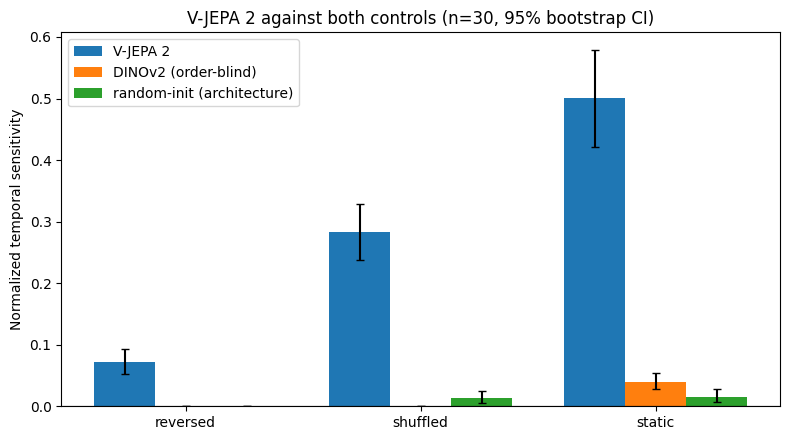

In [54]:
models = [("V-JEPA 2", vjepa_scores),
          ("DINOv2 (order-blind)", dino_scores),
          ("random-init (architecture)", rand_scores)]

x = np.arange(len(conditions))
width = 0.26

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, (label, sd) in enumerate(models):
    stats = [mean_and_err(sd, c) for c in conditions]
    ax.bar(x + (i - 1) * width, [s[0] for s in stats], width, label=label,
           yerr=[[s[1] for s in stats], [s[2] for s in stats]], capsize=3)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylabel("Normalized temporal sensitivity")
ax.set_title("V-JEPA 2 against both controls (n=30, 95% bootstrap CI)")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/fig1.png", dpi=150)
plt.show()

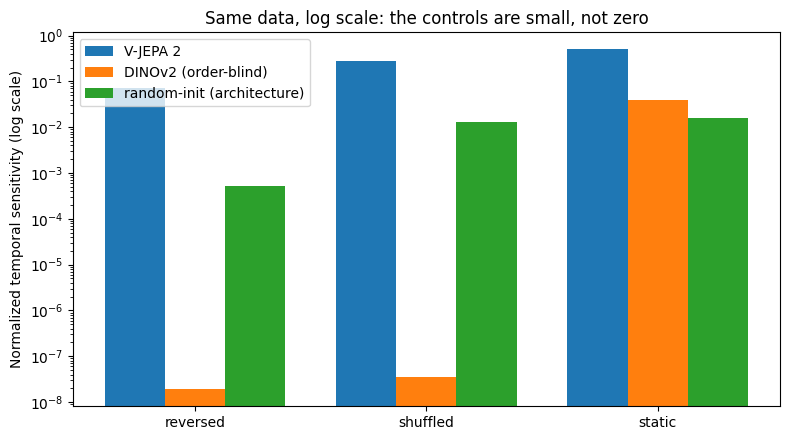

In [55]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for i, (label, sd) in enumerate(models):
    means = [max(statistics.mean(sd[c]), 1e-9) for c in conditions]
    ax.bar(x + (i - 1) * width, means, width, label=label)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylabel("Normalized temporal sensitivity (log scale)")
ax.set_title("Same data, log scale: the controls are small, not zero")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/fig2.png", dpi=150)
plt.show()

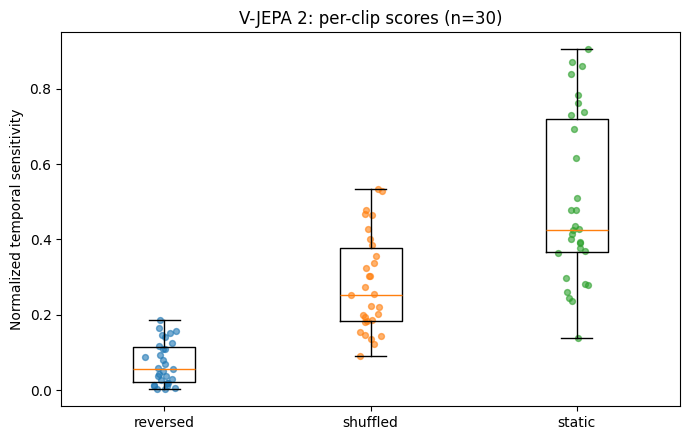

In [56]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([vjepa_scores[c] for c in conditions], tick_labels=conditions)

# jitter so overlapping points stay visible
for i, c in enumerate(conditions, 1):
    ax.scatter(np.random.default_rng(0).normal(i, 0.04, len(vjepa_scores[c])),
               vjepa_scores[c], alpha=0.6, s=18)

ax.set_ylabel("Normalized temporal sensitivity")
ax.set_title("V-JEPA 2: per-clip scores (n=30)")
plt.tight_layout()
plt.savefig("/kaggle/working/fig3.png", dpi=150)
plt.show()

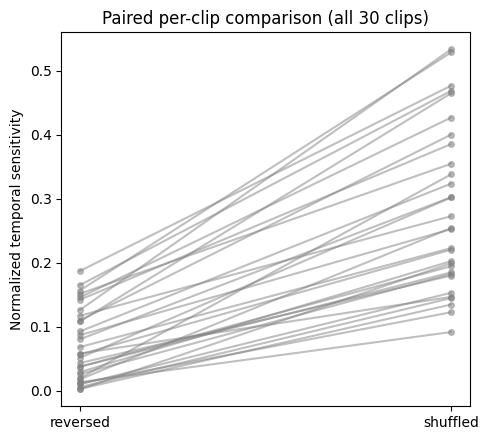

In [57]:
fig, ax = plt.subplots(figsize=(5, 4.5))

for r, s in zip(vjepa_scores["reversed"], vjepa_scores["shuffled"]):
    ax.plot([0, 1], [r, s], color="gray", alpha=0.5, marker="o", markersize=4)

ax.set_xticks([0, 1])
ax.set_xticklabels(["reversed", "shuffled"])
ax.set_ylabel("Normalized temporal sensitivity")
ax.set_title("Paired per-clip comparison (all 30 clips)")
plt.tight_layout()
plt.savefig("/kaggle/working/fig4.png", dpi=150)
plt.show()

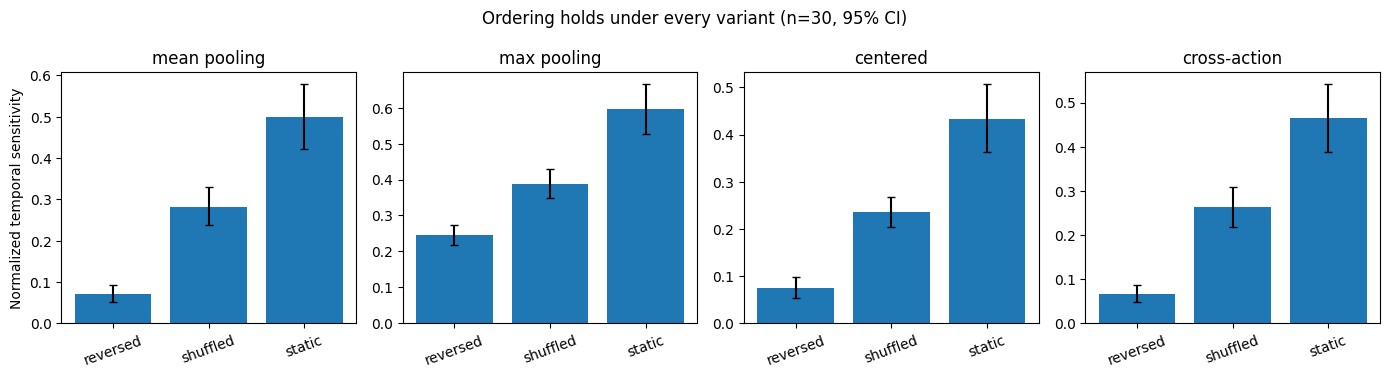

In [58]:
variants = [
    ("mean pooling",   vjepa_scores),
    ("max pooling",    vjepa_scores_max),
    ("centered",       vjepa_scores_centered),
    ("cross-action",   vjepa_scores_cross),
]

fig, axes = plt.subplots(1, len(variants), figsize=(14, 3.8))

for ax, (label, sd) in zip(axes, variants):
    stats = [mean_and_err(sd, c) for c in conditions]
    ax.bar(conditions, [s[0] for s in stats],
           yerr=[[s[1] for s in stats], [s[2] for s in stats]], capsize=3)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=20)

axes[0].set_ylabel("Normalized temporal sensitivity")
fig.suptitle("Ordering holds under every variant (n=30, 95% CI)")
plt.tight_layout()
plt.savefig("/kaggle/working/fig5.png", dpi=150)
plt.show()

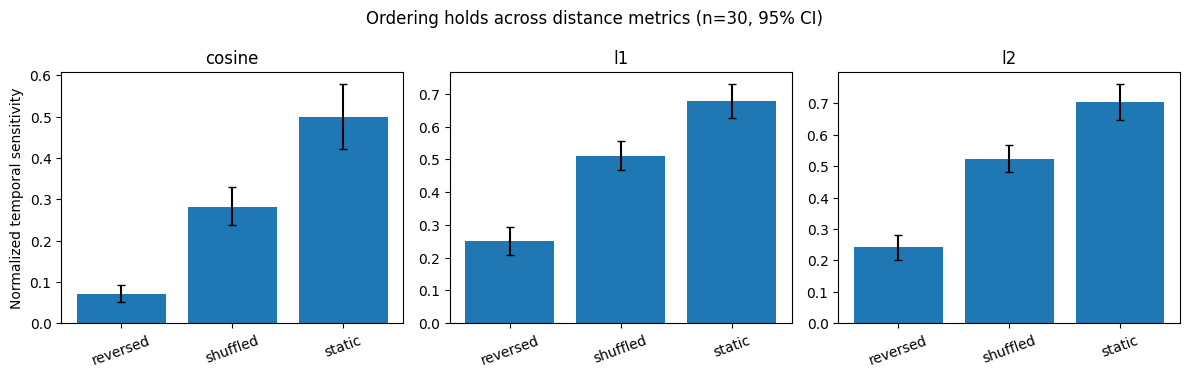

In [59]:
metrics = ["cosine", "l1", "l2"]
metric_scores = {}

for metric in metrics:
    metric_scores[metric] = {c: [] for c in conditions}
    for name in clip_names:
        others = [v for (n, c), v in vjepa_embeddings.items()
                  if c == "original" and n != name]
        for cond in conditions:
            metric_scores[metric][cond].append(
                compute_normalized_temporal_distance(
                    vjepa_embeddings[(name, "original")],
                    vjepa_embeddings[(name, cond)],
                    others, metric=metric,
                )
            )

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

for ax, metric in zip(axes, metrics):
    stats = [mean_and_err(metric_scores[metric], c) for c in conditions]
    ax.bar(conditions, [s[0] for s in stats],
           yerr=[[s[1] for s in stats], [s[2] for s in stats]], capsize=3)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)

axes[0].set_ylabel("Normalized temporal sensitivity")
fig.suptitle("Ordering holds across distance metrics (n=30, 95% CI)")
plt.tight_layout()
plt.savefig("/kaggle/working/fig6.png", dpi=150)
plt.show()

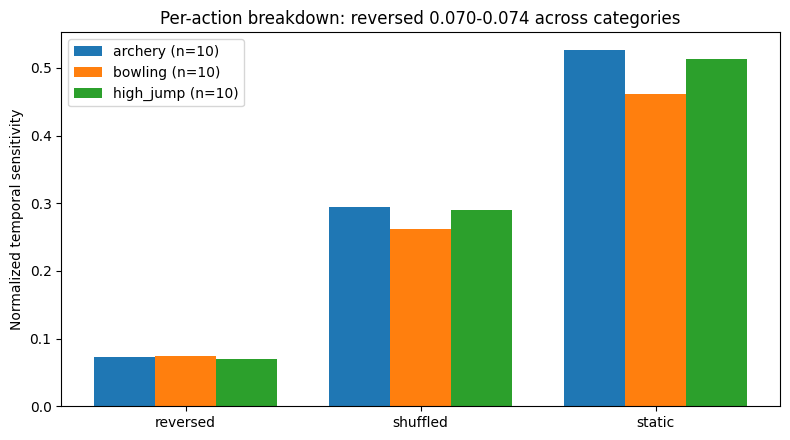

In [60]:
actions = cfg["data"]["actions"]

fig, ax = plt.subplots(figsize=(8, 4.5))
xa = np.arange(len(conditions))
w = 0.26

for i, act in enumerate(actions):
    idx = [j for j, n in enumerate(clip_names) if action_of(n) == act]
    means = [statistics.mean([vjepa_scores[c][j] for j in idx])
             for c in conditions]
    ax.bar(xa + (i - 1) * w, means, w, label=f"{act} (n={len(idx)})")

ax.set_xticks(xa)
ax.set_xticklabels(conditions)
ax.set_ylabel("Normalized temporal sensitivity")
ax.set_title("Per-action breakdown: reversed 0.070-0.074 across categories")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/fig7.png", dpi=150)
plt.show()

## Sources

- Assran et al. *V-JEPA 2.* arXiv:2506.09985 : objective, 3D RoPE,
  attentive-probe protocol.
- Bardes et al. *Revisiting Feature Prediction for Learning Visual
  Representations from Video.* arXiv:2404.08471, TMLR 2024 : 3.2 and
  Appendix E.4 for full-duration multiblock masking, eq. (2) for the L1
  loss, Table 3 for pooling, Table 8 for augmentations, 5.2 for
  Kinetics appearance cues.
- Oquab et al. *DINOv2.* arXiv:2304.07193 : 4, image-level objective
  on the class token.
- Sevilla-Lara et al. *Only Time Can Tell.* WACV 2021.
- facebookresearch/vjepa2, `configs/train/vitl16/cooldown-256px-64f.yaml`
  : mask temporal scale, frame rate, augmentations.